In [1]:
import json

with open("test_data_cleaned.jsonl", "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

model_id = "allenai/OLMoE-1B-7B-0924"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map="auto"
)
model.eval()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

OlmoeForCausalLM(
  (model): OlmoeModel(
    (embed_tokens): Embedding(50304, 2048, padding_idx=1)
    (layers): ModuleList(
      (0-15): 16 x OlmoeDecoderLayer(
        (self_attn): OlmoeSdpaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (q_norm): OlmoeRMSNorm((2048,), eps=1e-05)
          (k_norm): OlmoeRMSNorm((2048,), eps=1e-05)
        )
        (mlp): OlmoeSparseMoeBlock(
          (gate): Linear4bit(in_features=2048, out_features=64, bias=False)
          (experts): ModuleList(
            (0-63): 64 x OlmoeMLP(
              (gate_proj): Linear4bit(in_features=2048, out_features=1024, bias=False)
              (up_proj): Linear4bit(in_features=2048, out_features=1024, bias=False)
        

In [3]:
# Dictionary to store the router outputs
router_logs = {}

def get_router_hook(layer_name):
    def hook(module, inputs, outputs):
        # Robustly handle tuple vs tensor outputs
        # OLMoE routers often return a tuple where [1] is the logits
        if isinstance(outputs, tuple):
            val = outputs[1] 
        else:
            val = outputs
        
        # Only capture if it matches the expert count (64 for OLMoE)
        if isinstance(val, torch.Tensor) and val.shape[-1] == 64:
            # Detach and move to CPU to save GPU memory
            router_logs[layer_name] = val.detach().float().cpu()
    return hook

# Clear old hooks (if re-running)
for name, module in model.named_modules():
    if hasattr(module, "_forward_hooks"):
        module._forward_hooks.clear()

# Attach new hooks to the router layers
print("Attaching spy hooks...")
hook_count = 0
for name, module in model.named_modules():
    # We target the specific gate layer in the OLMoE architecture
    if name.endswith("mlp.gate"): 
        module.register_forward_hook(get_router_hook(name))
        hook_count += 1

print(f"Attached {hook_count} hooks (Expect 32 for this model).")

Attaching spy hooks...
Attached 16 hooks (Expect 32 for this model).


In [4]:
from collections import defaultdict
from tqdm import tqdm

router_data = []

for i, item in enumerate(tqdm(test_data)):
    lang = item["lang"]
    text = item["text"]
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    router_logs.clear()

    with torch.no_grad():
        _ = model(**inputs)

    layer_name = "model.layers.14.mlp.gate"
    if layer_name in router_logs:
        logits = router_logs[layer_name]  # [seq_len, num_experts]
        expert_ids = logits.argmax(dim=-1).tolist()

        token_strs = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
        for idx, expert in enumerate(expert_ids):
            router_data.append({
                "lang": lang,
                "sentence_id": i,
                "token_idx": idx,
                "token_str": token_strs[idx],
                "expert_id": expert
            })

100%|█████████████████████████████████████████████████████████████████████████████| 4000/4000 [1:05:15<00:00,  1.02it/s]


In [5]:
import pandas as pd
# polarspel

df = pd.DataFrame(router_data)
df.to_csv("raw_router_logs.csv", index=False)
# try parquet

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("raw_router_logs.csv")
print(df.head())
print(df.columns)

       lang  sentence_id  token_idx  token_str  expert_id
0  eng_Latn            0          0       Many         60
1  eng_Latn            0          1  Ġidentify         16
2  eng_Latn            0          2        Ġas         54
3  eng_Latn            0          3     Ġqueer         46
4  eng_Latn            0          4          ,          5
Index(['lang', 'sentence_id', 'token_idx', 'token_str', 'expert_id'], dtype='object')


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

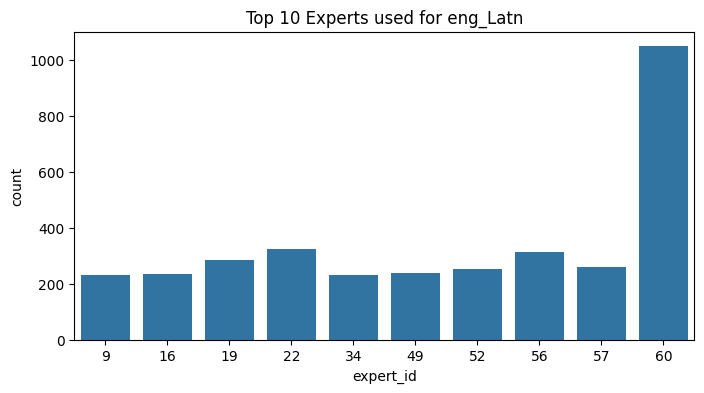

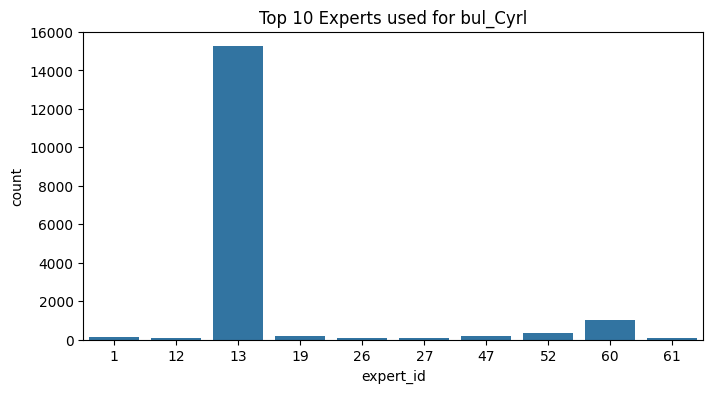

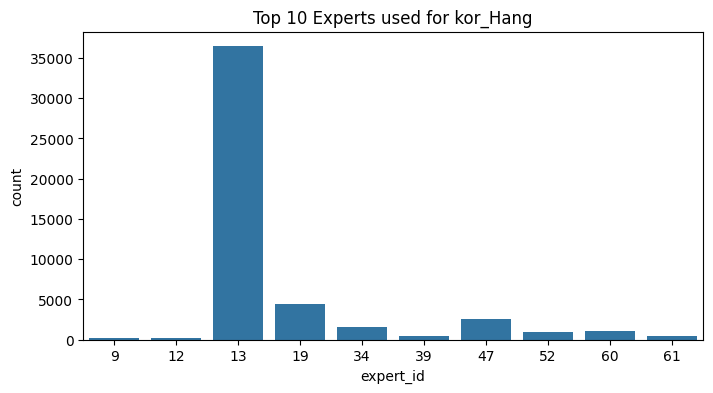

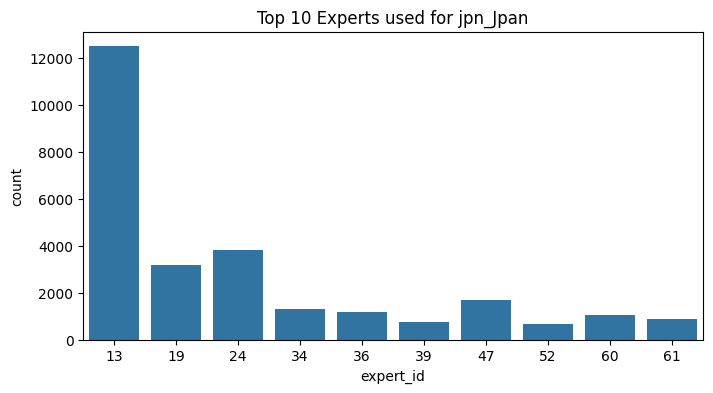

In [4]:
top_experts = df.groupby(['lang', 'expert_id']).size().reset_index(name='count')
top_experts = top_experts.sort_values(['lang', 'count'], ascending=[True, False])

for lang in df['lang'].unique():
    subset = top_experts[top_experts['lang'] == lang].head(10)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=subset, x='expert_id', y='count')
    plt.title(f"Top 10 Experts used for {lang}")
    plt.show()